# Установка и импорты

In [1]:
!pip install -q torch torchvision matplotlib numpy tqdm tensorboard

import os
import math
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
from torchvision.utils import make_grid, save_image
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingLR

from torch.utils.tensorboard import SummaryWriter
import datetime

# Монтирование Drive и загрузка данных

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # нормализуем в диапазон [-1, 1], т.к. многие модели лучше работают с симметричным входом
])

train_dataset = datasets.SVHN(root='./data', split='train', download=True, transform=transform)
test_dataset  = datasets.SVHN(root='./data', split='test', download=True, transform=transform)

100%|██████████| 182M/182M [00:20<00:00, 8.71MB/s]
100%|██████████| 64.3M/64.3M [00:04<00:00, 14.9MB/s]


In [4]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Exploratory data analysis

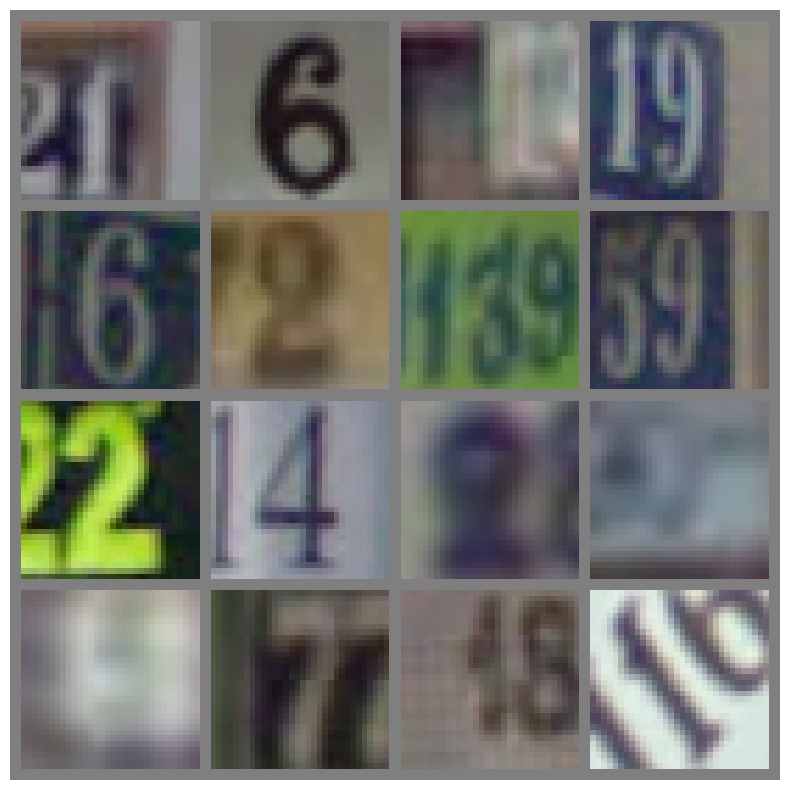

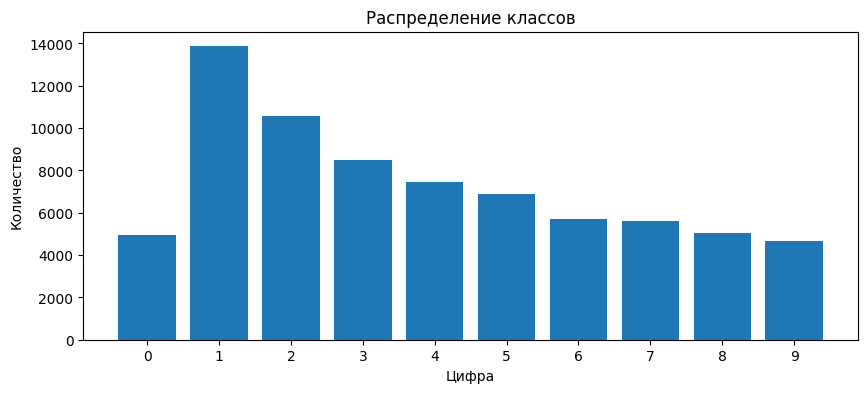


Количество примеров в каждом классе:
Цифра 0: 4948 примеров
Цифра 1: 13861 примеров
Цифра 2: 10585 примеров
Цифра 3: 8497 примеров
Цифра 4: 7458 примеров
Цифра 5: 6882 примеров
Цифра 6: 5727 примеров
Цифра 7: 5595 примеров
Цифра 8: 5045 примеров
Цифра 9: 4659 примеров
Всего: 73257 примеров


In [5]:
def imshow(img, title=None):
    img = img / 2 + 0.5          # денормализация из [-1,1] в [0,1]
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title:
        plt.title(title)

images, labels = next(iter(train_loader))
plt.figure(figsize=(10, 10))
grid = make_grid(images[:16], nrow=4)
grid = grid / 2 + 0.5
plt.imshow(grid.permute(1,2,0).cpu())
plt.axis('off')
plt.show()


all_labels = []
for _, lbl in train_loader:
    all_labels.extend(lbl.numpy())
all_labels = np.array(all_labels)

plt.figure(figsize=(10, 4))
plt.hist(all_labels, bins=np.arange(-0.5, 10.5, 1), rwidth=0.8, align='mid')
plt.xticks(range(10))
plt.title('Распределение классов')
plt.xlabel('Цифра')
plt.ylabel('Количество')
plt.show()

unique, counts = np.unique(all_labels, return_counts=True)
print("\nКоличество примеров в каждом классе:")
for digit, count in zip(unique, counts):
    print(f"Цифра {digit}: {count} примеров")
print(f"Всего: {len(all_labels)} примеров")

Видно, что количество примеров в разных классах неодинаковое, поэтому проведем аугментацию данных

# Аугментация

In [6]:
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class AugmentedSVHN(Dataset):
    def __init__(self, original_dataset, target_samples_per_class=None, noise_std=0.05):
        self.original = original_dataset
        self.target_samples_per_class = target_samples_per_class
        self.noise_std = noise_std

        self.class_counts = {}
        for _, label in original_dataset:
            label = int(label)
            self.class_counts[label] = self.class_counts.get(label, 0) + 1

        if target_samples_per_class is None:
            self.target_samples_per_class = max(self.class_counts.values())

        self.indices_by_class = {c: [] for c in range(10)}
        for idx, (_, label) in enumerate(original_dataset):
            self.indices_by_class[int(label)].append(idx)

        self.all_indices = []
        self.augment_flags = []
        for cls in range(10):
            current_count = len(self.indices_by_class[cls])
            needed = self.target_samples_per_class - current_count
            # Добавляем все оригинальные
            for idx in self.indices_by_class[cls]:
                self.all_indices.append(idx)
                self.augment_flags.append(False)
            # Добавляем аугментированные
            for _ in range(needed):
                orig_idx = np.random.choice(self.indices_by_class[cls])
                self.all_indices.append(orig_idx)
                self.augment_flags.append(True)
        # Перемешиваем
        shuffled = list(zip(self.all_indices, self.augment_flags))
        np.random.shuffle(shuffled)
        self.all_indices, self.augment_flags = zip(*shuffled)

    def __len__(self):
        return len(self.all_indices)

    def __getitem__(self, idx):
        orig_idx = self.all_indices[idx]
        img, label = self.original[orig_idx]
        if self.augment_flags[idx]:
            # Применяем аугментацию
            # 1. Вращение на случайный угол от -15 до 15 градусов
            angle = np.random.uniform(-15, 15)
            img = transforms.functional.rotate(img, angle, fill=0)
            # 2. Добавляем шум
            noise = torch.randn_like(img) * self.noise_std
            img = img + noise
            # 3. Нормализация
            img = torch.clamp(img, -1, 1)
        return img, label

In [7]:
augmented_train = AugmentedSVHN(train_dataset, target_samples_per_class=13861, noise_std=0.05)

augmented_loader = DataLoader(augmented_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

Распределение классов после аугментации:
Цифра 0: 13861 примеров
Цифра 1: 13861 примеров
Цифра 2: 13861 примеров
Цифра 3: 13861 примеров
Цифра 4: 13861 примеров
Цифра 5: 13861 примеров
Цифра 6: 13861 примеров
Цифра 7: 13861 примеров
Цифра 8: 13861 примеров
Цифра 9: 13861 примеров
Всего: 138610 примеров


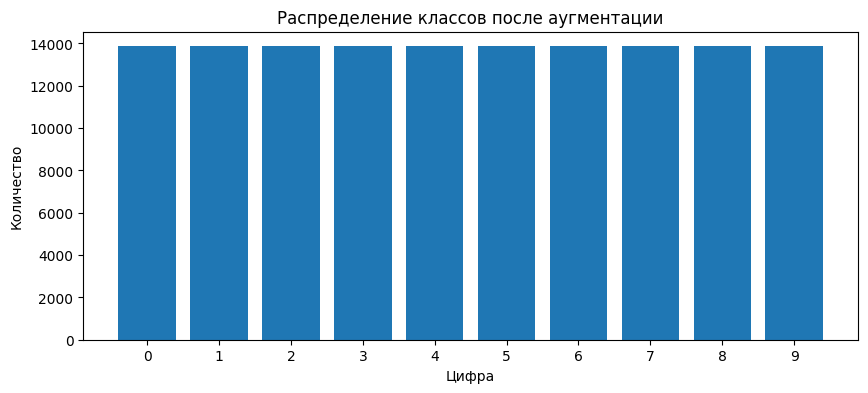

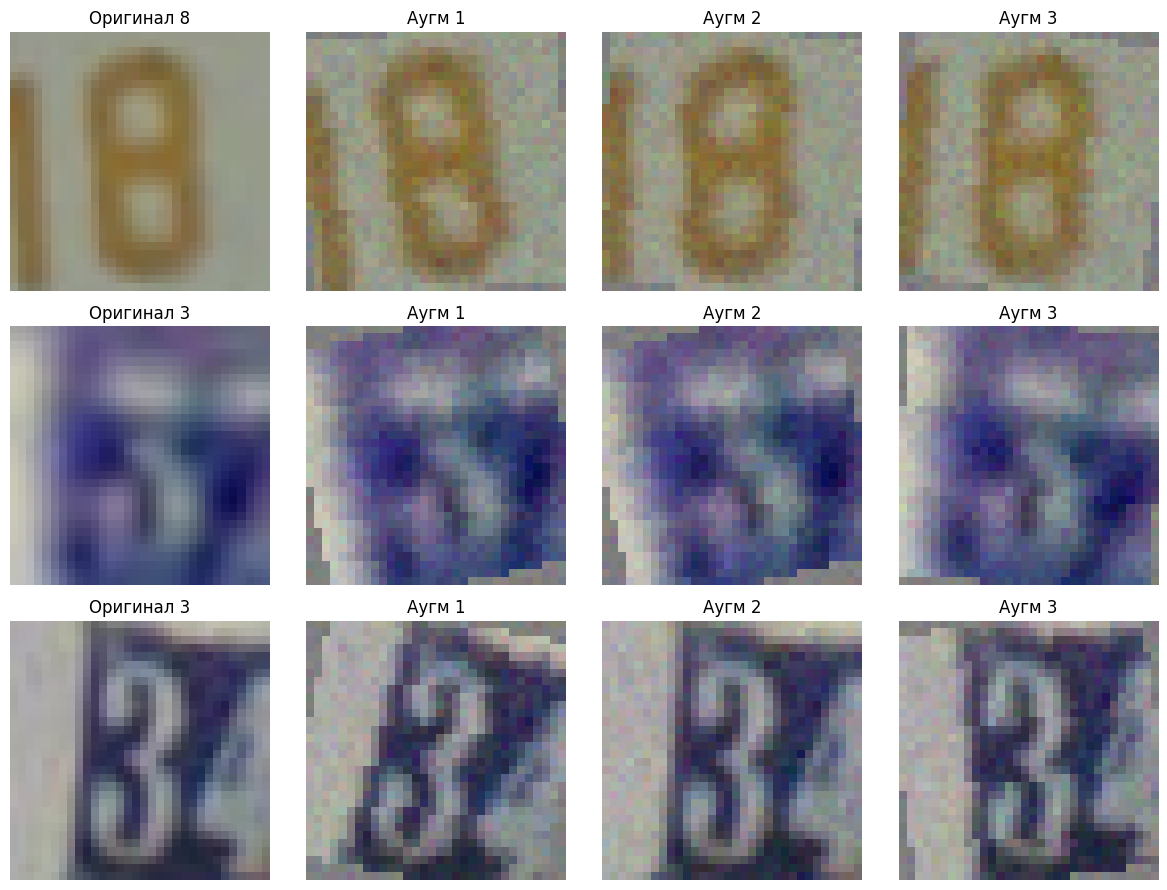

In [8]:
print("Распределение классов после аугментации:")
counts = [0]*10
for _, lbl in augmented_train:
    counts[lbl] += 1
for i, cnt in enumerate(counts):
    print(f"Цифра {i}: {cnt} примеров")
print(f"Всего: {sum(counts)} примеров")

plt.figure(figsize=(10, 4))
plt.hist([lbl for _, lbl in augmented_train], bins=np.arange(-0.5, 10.5, 1), rwidth=0.8, align='mid')
plt.xticks(range(10))
plt.title('Распределение классов после аугментации')
plt.xlabel('Цифра')
plt.ylabel('Количество')
plt.show()


def visualize_augmentations(dataset, num_samples=3, num_augments=3):
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    fig, axes = plt.subplots(num_samples, num_augments+1, figsize=(3*(num_augments+1), 3*num_samples))
    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        # Оригинал
        axes[i, 0].imshow(img.permute(1,2,0).cpu() / 2 + 0.5)
        axes[i, 0].set_title(f"Оригинал {label}")
        axes[i, 0].axis('off')
        # Генерируем аугментированные версии (те же операции, что в AugmentedSVHN)
        for aug in range(num_augments):
            aug_img = img.clone()
            angle = np.random.uniform(-15, 15)
            aug_img = transforms.functional.rotate(aug_img, angle, fill=0)
            noise = torch.randn_like(aug_img) * 0.05
            aug_img = aug_img + noise
            aug_img = torch.clamp(aug_img, -1, 1)
            axes[i, aug+1].imshow(aug_img.permute(1,2,0).cpu() / 2 + 0.5)
            axes[i, aug+1].set_title(f"Аугм {aug+1}")
            axes[i, aug+1].axis('off')
    plt.tight_layout()
    plt.show()

visualize_augmentations(train_dataset, num_samples=3, num_augments=3)

Проверяем устройство

In [9]:
if 'device' not in locals():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Используется устройство: {device}")

Используется устройство: cuda


# Variational autoencoder

VAE (Variational Autoencoder) - генеративная модель, которая сжимает входное изображение в вероятностное латентное пространство (mu и logvar) и учится восстанавливать исходную картинку из случайной точки в этом пространстве. Энкодер свёрточный с шагом 2 (размерность уменьшается в 8 раз), декодер: симметричная транспонированная свёртка с tanh на выходе. Репараметризация позволяет обучаться через градиентный спуск.

In [10]:
class VAEEncoder(nn.Module):
    def __init__(self, latent_dim=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, stride=2, padding=1)
        self.fc_mu = nn.Linear(64 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(64 * 4 * 4, latent_dim)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

In [11]:
class VAEDecoder(nn.Module):
    def __init__(self, latent_dim=10):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 64 * 4 * 4)
        self.deconv1 = nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1)
        self.deconv2 = nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1)
        self.deconv3 = nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1)

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 64, 4, 4)
        x = F.relu(self.deconv1(x))
        x = F.relu(self.deconv2(x))
        x = torch.tanh(self.deconv3(x))
        return x

In [12]:
class VAE(nn.Module):
    def __init__(self, latent_dim=10):
        super().__init__()
        self.encoder = VAEEncoder(latent_dim)
        self.decoder = VAEDecoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

In [13]:
def vae_loss(recon, x, mu, logvar):
    recon_loss = F.mse_loss(recon, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss, recon_loss, kl_loss

def train_vae(vae, train_loader, epochs=50, lr=1e-3, device='cuda'):
    vae.to(device)
    optimizer = optim.Adam(vae.parameters(), lr=lr)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

    train_losses = []
    recon_losses = []
    kl_losses = []
    mae_history = []

    for epoch in range(epochs):
        vae.train()
        total_loss = 0
        total_recon = 0
        total_kl = 0
        total_mae = 0
        count = 0

        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        for batch_idx, (data, _) in enumerate(pbar):
            data = data.to(device)
            optimizer.zero_grad()
            recon, mu, logvar = vae(data)
            loss, recon_loss, kl_loss = vae_loss(recon, data, mu, logvar)
            loss.backward()
            optimizer.step()

            batch_size = data.size(0)
            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()
            mae = torch.mean(torch.abs(recon - data)).item() * batch_size
            total_mae += mae
            count += batch_size

            pbar.set_postfix({'loss': loss.item() / batch_size,
                              'recon': recon_loss.item() / batch_size,
                              'kl': kl_loss.item() / batch_size,
                              'mae': mae / batch_size})

        avg_loss = total_loss / count
        avg_recon = total_recon / count
        avg_kl = total_kl / count
        avg_mae = total_mae / count
        train_losses.append(avg_loss)
        recon_losses.append(avg_recon)
        kl_losses.append(avg_kl)
        mae_history.append(avg_mae)

        scheduler.step()
        print(f'Epoch {epoch+1}: Loss = {avg_loss:.4f}, Recon = {avg_recon:.4f}, KL = {avg_kl:.4f}, MAE = {avg_mae:.4f}')

    return train_losses, recon_losses, kl_losses, mae_history

Epoch 1/30:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 1: Loss = 146.7390, Recon = 129.9070, KL = 16.8320, MAE = 0.1508


Epoch 2/30:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 2: Loss = 110.1799, Recon = 92.4065, KL = 17.7733, MAE = 0.1274


Epoch 3/30:   0%|          | 0/1145 [00:00<?, ?it/s]

...

Epoch 28: Loss = 101.8294, Recon = 84.3489, KL = 17.4805, MAE = 0.1203


Epoch 29/30:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 29: Loss = 101.8262, Recon = 84.3209, KL = 17.5053, MAE = 0.1203


Epoch 30/30:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 30: Loss = 101.7864, Recon = 84.3024, KL = 17.4840, MAE = 0.1203


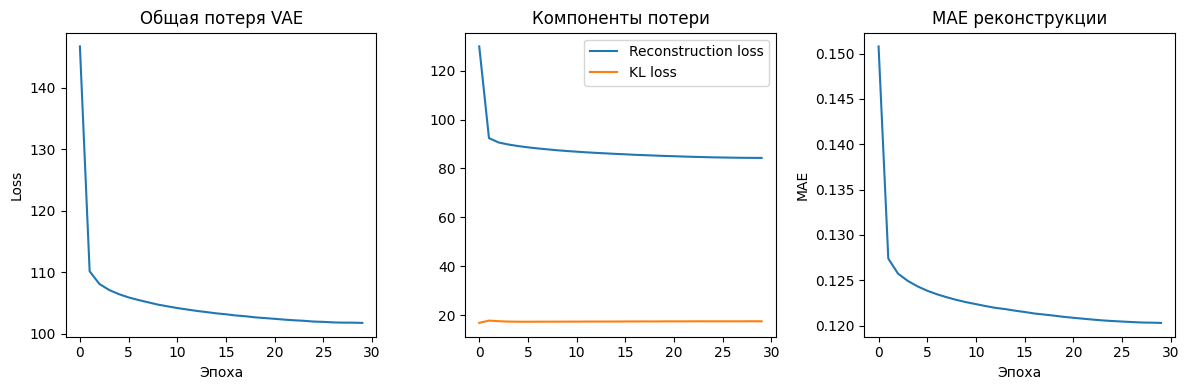

In [15]:
vae = VAE(latent_dim=10)
vae_losses, recon_losses, kl_losses, mae_history = train_vae(vae, train_loader, epochs=30, lr=1e-3, device=device)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(vae_losses)
plt.title('Общая потеря VAE')
plt.xlabel('Эпоха')
plt.ylabel('Loss')

plt.subplot(1, 3, 2)
plt.plot(recon_losses, label='Reconstruction loss')
plt.plot(kl_losses, label='KL loss')
plt.legend()
plt.title('Компоненты потери')

plt.subplot(1, 3, 3)
plt.plot(mae_history)
plt.title('MAE реконструкции')
plt.xlabel('Эпоха')
plt.ylabel('MAE')

plt.tight_layout()
plt.show()

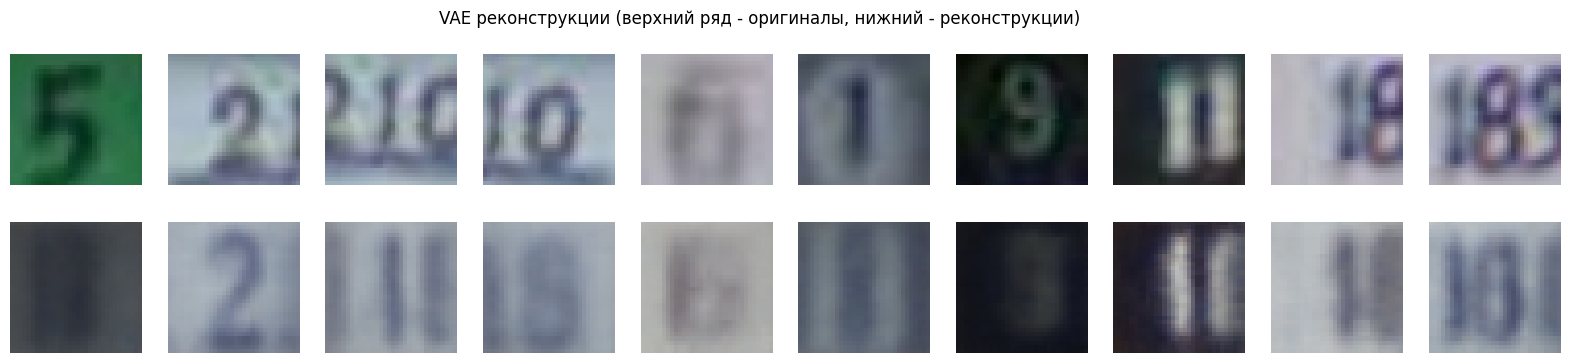

In [16]:
vae.eval()
test_iter = iter(test_loader)
test_images, test_labels = next(test_iter)
test_images = test_images.to(device)

with torch.no_grad():
    recon, _, _ = vae(test_images)

def denorm(img):
    return img / 2 + 0.5

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i+1)
    plt.imshow(denorm(test_images[i].cpu()).permute(1,2,0))
    plt.axis('off')
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(denorm(recon[i].cpu()).permute(1,2,0))
    plt.axis('off')
plt.suptitle('VAE реконструкции (верхний ряд - оригиналы, нижний - реконструкции)')
plt.show()

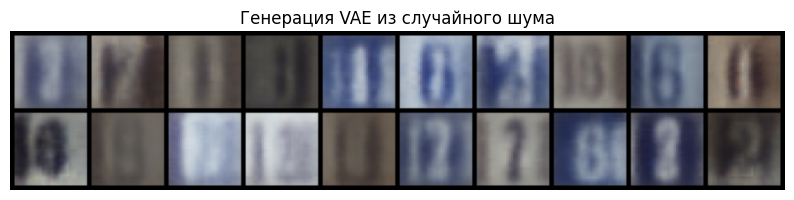

In [17]:
with torch.no_grad():
    z = torch.randn(20, 10).to(device)
    generated = vae.decoder(z)
    generated = denorm(generated).cpu()

plt.figure(figsize=(10, 4))
grid = make_grid(generated, nrow=10, padding=2)
plt.imshow(grid.permute(1,2,0))
plt.axis('off')
plt.title('Генерация VAE из случайного шума')
plt.show()

Сохраняем модель.

In [19]:
# Путь к папке
save_dir = '/content/drive/MyDrive/pet_project_models'
os.makedirs(save_dir, exist_ok=True)
print(f"Папка для сохранения: {save_dir}")

Папка для сохранения: /content/drive/MyDrive/pet_project_models


In [20]:
# Сохранение VAE
vae_name = f"vae_ep30_bs{batch_size}_latent10"
vae_path = os.path.join(save_dir, f"{vae_name}.pth")
torch.save(vae.state_dict(), vae_path)

vae_config = {
    'latent_dim': 10,
    'image_channels': 3,
    'epochs_trained': 30,
    'batch_size': batch_size,
    'loss': 'MSE+KL',
}
torch.save(vae_config, os.path.join(save_dir, f"{vae_name}_config.pth"))

vae_history = {
    'loss': vae_losses,
    'recon_loss': recon_losses,
    'kl_loss': kl_losses,
    'mae': mae_history,
}
torch.save(vae_history, os.path.join(save_dir, f"{vae_name}_history.pth"))

# Denoising Diffusion Probabilistic Model

DDPM (Denoising Diffusion Probabilistic Model) постепенно зашумляет изображение за 1000 шагов и учится восстанавливать его обратно, предсказывая добавленный шум. Модель условная: UNet получает эмбеддинг времени (синусоидальный) и эмбеддинг цифры (10 классов). NoiseScheduler предвычисляет коэффициенты для прямого и обратного процессов (линейное расписание betas).

In [ ]:
class NoiseScheduler:
    def __init__(self, num_timesteps=1000, beta_start=1e-4, beta_end=0.02, schedule='linear'):
        self.num_timesteps = num_timesteps
        if schedule == 'linear':
            self.betas = torch.linspace(beta_start, beta_end, num_timesteps)
        elif schedule == 'cosine':
            # косинусное расписание
            steps = num_timesteps + 1
            x = torch.linspace(0, num_timesteps, steps)
            alphas_cumprod = torch.cos(((x / num_timesteps) + 0.008) / (1 + 0.008) * math.pi / 2) ** 2
            alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
            betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
            betas = torch.clip(betas, 0.0001, 0.9999)
            self.betas = betas
        else:
            raise ValueError(f'Unknown schedule {schedule}')

        self.alphas = 1. - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.)

        # Коэффициенты для forward diffusion
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - self.alphas_cumprod)

        # Коэффициенты для обратного процесса (posterior)
        self.posterior_variance = self.betas * (1. - self.alphas_cumprod_prev) / (1. - self.alphas_cumprod)
        self.posterior_mean_coef1 = self.betas * torch.sqrt(self.alphas_cumprod_prev) / (1. - self.alphas_cumprod)
        self.posterior_mean_coef2 = (1. - self.alphas_cumprod_prev) * torch.sqrt(self.alphas) / (1. - self.alphas_cumprod)

    def q_sample(self, x0, t, noise=None):
        """Добавить шум к x0 на шаге t"""
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_alpha_cumprod_t = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
        sqrt_one_minus_alpha_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        return sqrt_alpha_cumprod_t * x0 + sqrt_one_minus_alpha_cumprod_t * noise, noise

    def q_posterior(self, x0, xt, t):
        """Вычислить среднее и дисперсию q(x_{t-1}|x_t, x0)"""
        posterior_mean = (
            self.posterior_mean_coef1[t].view(-1,1,1,1) * x0 +
            self.posterior_mean_coef2[t].view(-1,1,1,1) * xt
        )
        posterior_variance = self.posterior_variance[t]
        return posterior_mean, posterior_variance

    def p_sample(self, model, xt, t, classes, clip_denoised=True):
        """Один шаг обратного процесса: предсказать x_{t-1}"""
        t_batch = torch.full((xt.shape[0],), t, device=xt.device, dtype=torch.long)
        predicted_noise = model(xt, t_batch, classes)
        # Предсказать x0 из xt и предсказанного шума
        alpha_cumprod_t = self.alphas_cumprod[t].view(-1,1,1,1)
        sqrt_alpha_cumprod_t = self.sqrt_alphas_cumprod[t].view(-1,1,1,1)
        sqrt_one_minus_alpha_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1,1,1,1)
        pred_x0 = (xt - sqrt_one_minus_alpha_cumprod_t * predicted_noise) / sqrt_alpha_cumprod_t
        if clip_denoised:
            pred_x0 = torch.clamp(pred_x0, -1., 1.)

        # Вычислить среднее и дисперсию q(x_{t-1}|x_t, x0)
        mean, variance = self.q_posterior(pred_x0, xt, t)
        if t == 0:
            return mean
        else:
            noise = torch.randn_like(xt)
            return mean + torch.sqrt(variance).view(-1,1,1,1) * noise

    def sample(self, model, num_samples, classes, img_shape=(3,32,32), device='cuda', clip_denoised=True):
        """Генерация изображений из случайного шума"""
        model.eval()
        with torch.no_grad():
            xt = torch.randn((num_samples,) + img_shape, device=device)
            for t in reversed(range(self.num_timesteps)):
                xt = self.p_sample(model, xt, t, classes, clip_denoised)
            return xt

    def to(self, device):
        """Переместить все предвычисленные тензоры на указанное устройство"""
        self.betas = self.betas.to(device)
        self.alphas = self.alphas.to(device)
        self.alphas_cumprod = self.alphas_cumprod.to(device)
        self.alphas_cumprod_prev = self.alphas_cumprod_prev.to(device)
        self.sqrt_alphas_cumprod = self.sqrt_alphas_cumprod.to(device)
        self.sqrt_one_minus_alphas_cumprod = self.sqrt_one_minus_alphas_cumprod.to(device)
        self.posterior_variance = self.posterior_variance.to(device)
        self.posterior_mean_coef1 = self.posterior_mean_coef1.to(device)
        self.posterior_mean_coef2 = self.posterior_mean_coef2.to(device)
        return self

Синусоидальные эмбединги вычисляем согласно формуле:

$\text{PE}(t, 2i) = \sin\left( t / 10000^{2i/d} \right), \quad \text{PE}(t, 2i+1) = \cos\left( t / 10000^{2i/d} \right)$

In [ ]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

Self-Attention для пространственных признаков (аналог non-local блока). Входная карта признаков `x` (B×C×H×W) через свёртки 1×1 превращается в query (Q) и key (K) с пониженной размерностью `C/reduction` и value (V) с полной размерностью `C`. Attention-веса вычисляются как `softmax(Q·K^T / sqrt(C'))`, затем применяются к V. Результат добавляется к исходному входу (residual connection). Это позволяет модели учитывать глобальные зависимости между пикселями.

In [ ]:
class SelfAttention(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.channels = channels
        self.reduction = reduction
        self.q_conv = nn.Conv2d(channels, channels // reduction, 1)
        self.k_conv = nn.Conv2d(channels, channels // reduction, 1)
        self.v_conv = nn.Conv2d(channels, channels, 1)
        self.out_conv = nn.Conv2d(channels, channels, 1)
        self.scale = (channels // reduction) ** -0.5

    def forward(self, x):
        B, C, H, W = x.shape
        # q, k, v: [B, C', H, W] -> [B, H*W, C'] / [B, C', H*W] / [B, H*W, C]
        q = self.q_conv(x).view(B, -1, H*W).permute(0,2,1)  # [B, H*W, C']
        k = self.k_conv(x).view(B, -1, H*W)                 # [B, C', H*W]
        v = self.v_conv(x).view(B, -1, H*W).permute(0,2,1) # [B, H*W, C]
        # attention: softmax( q @ k^T / sqrt(C') )  -> [B, H*W, H*W]
        attn = torch.bmm(q, k) * self.scale
        attn = F.softmax(attn, dim=-1)
        out = torch.bmm(attn, v).permute(0,2,1).view(B, C, H, W)
        out = self.out_conv(out)
        return x + out

Базовый блок UNet с поддержкой даунсемплинга (`down`), апсемплинга (`up`) и residual connection через attention. Содержит два свёрточных слоя 3×3 с BatchNorm и ReLU, в которые аддитивно встраиваются эмбеддинги времени и класса (после первого свёрточного слоя). При включённом `use_attention` применяется SelfAttention. В конце, если задан `up` или `down`, размер карты признаков меняется вдвое (транспонированная свёртка или свёртка с шагом 2).

In [ ]:
class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, class_emb_dim, up=False, down=False, use_attention=False):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch) if time_emb_dim else None
        self.class_mlp = nn.Linear(class_emb_dim, out_ch) if class_emb_dim else None
        if up:
            self.conv1 = nn.Conv2d(2*in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        elif down:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Identity()

        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU()
        self.use_attention = use_attention
        if use_attention:
            self.attention = SelfAttention(out_ch)
        else:
            self.attention = None

    def forward(self, x, t=None, class_labels=None):
        h = self.act(self.bnorm1(self.conv1(x)))
        if self.time_mlp and t is not None:
            time_emb = self.time_mlp(t)
            h = h + time_emb[:, :, None, None]
        if self.class_mlp and class_labels is not None:
            class_emb = self.class_mlp(class_labels)
            h = h + class_emb[:, :, None, None]
        h = self.act(self.bnorm2(self.conv2(h)))
        if self.attention is not None:
            h = self.attention(h)
        return self.transform(h)

UNet для условной диффузионной модели. Энкодер последовательно уменьшает пространственное разрешение (64 → 128 → 256 каналов), декодер восстанавливает его обратно с skip-соединениями через `cat`. На уровнях `down2` и `up2` добавлены SelfAttention для захвата глобальных зависимостей. Эмбеддинги времени (через синусоидальное кодирование + MLP) и класса (Embedding) подаются в каждый блок, интегрируясь после первого свёрточного слоя.

In [ ]:
class SimpleUNet(nn.Module):
    def __init__(self, image_channels=3, time_emb_dim=128, class_emb_dim=10, num_classes=10):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )
        self.class_mlp = nn.Embedding(num_classes, class_emb_dim)

        # Энкодер
        self.down1 = Block(image_channels, 64, time_emb_dim, class_emb_dim, down=True)
        self.down2 = Block(64, 128, time_emb_dim, class_emb_dim, down=True, use_attention=True)
        self.down3 = Block(128, 256, time_emb_dim, class_emb_dim, down=True)

        # Bottleneck
        self.bottleneck = Block(256, 256, time_emb_dim, class_emb_dim, use_attention=True)

        # Декодер
        self.up3 = Block(256, 128, time_emb_dim, class_emb_dim, up=True)
        self.up2 = Block(128, 64, time_emb_dim, class_emb_dim, up=True, use_attention=True)
        self.up1 = Block(64, 64, time_emb_dim, class_emb_dim, up=True)

        self.out = nn.Conv2d(64, image_channels, 1)

    def forward(self, x, t, class_labels):
        # Временной эмбединг
        t_emb = self.time_mlp(t)
        # Эмбединг класса
        c_emb = self.class_mlp(class_labels)

        d1 = self.down1(x, t_emb, c_emb)
        d2 = self.down2(d1, t_emb, c_emb)
        d3 = self.down3(d2, t_emb, c_emb)

        b = self.bottleneck(d3, t_emb, c_emb)

        u3 = self.up3(torch.cat([b, d3], dim=1), t_emb, c_emb)
        u2 = self.up2(torch.cat([u3, d2], dim=1), t_emb, c_emb)
        u1 = self.up1(torch.cat([u2, d1], dim=1), t_emb, c_emb)

        return self.out(u1)

Модель учится предсказывать добавленный шум для случайного временного шага t (MSE loss). На каждом шаге оптимизатор Adam с косинусным планировщиком, дополнительно логируется MAE. Каждые 5 эпох генерируется 20 примеров (по 2 на каждый класс) для визуального контроля качества.

Epoch 1/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 1: Loss = 0.1960, MAE = 0.3172


Epoch 2/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 2: Loss = 0.0494, MAE = 0.1606


Epoch 3/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 3: Loss = 0.0344, MAE = 0.1247


Epoch 4/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 4: Loss = 0.0283, MAE = 0.1090


Epoch 5/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 5: Loss = 0.0251, MAE = 0.1005


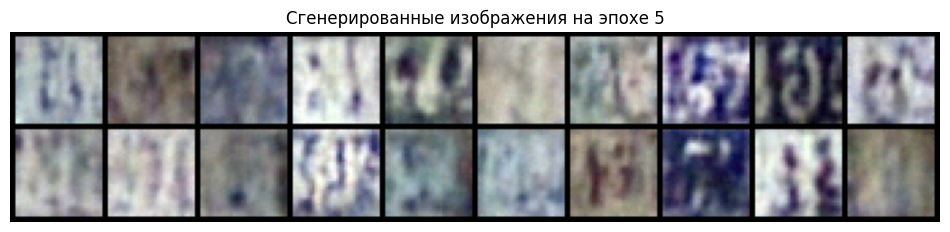

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bdb5408e480><function _MultiProcessingDataLoaderIter.__del__ at 0x7bdb5408e480>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
self._shutdown_workers()    
if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

       if w.is_alive():  
    ^    ^^ ^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'

  File "/usr/lib/python

Epoch 6/120:   0%|          | 0/1145 [00:01<?, ?it/s]

 ^ ^^^ ^^^ ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
^AssertionError^: ^can only test a child process^
^^^^^^^^^^^
AssertionError: can only test a child process


Epoch 6: Loss = 0.0239, MAE = 0.0961


Epoch 7/120:   0%|          | 0/1145 [00:00<?, ?it/s]

...

Epoch 8: Loss = 0.0214, MAE = 0.0891


Epoch 9/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 9: Loss = 0.0211, MAE = 0.0878


Epoch 10/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 10: Loss = 0.0208, MAE = 0.0863


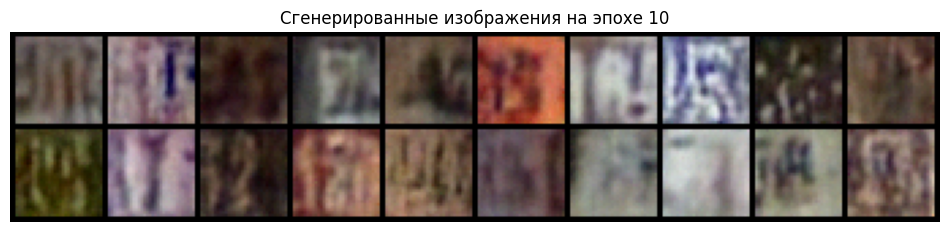

Epoch 11/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 11: Loss = 0.0195, MAE = 0.0838


Epoch 12/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 12: Loss = 0.0193, MAE = 0.0831


Epoch 13/120:   0%|          | 0/1145 [00:00<?, ?it/s]

...

Epoch 14/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bdb5408e480>Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7bdb5408e480>Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        self._shutdown_workers()self._shutdown_workers()Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bdb5408e480>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1653, in _shutdown_workers
    self._pin_memory_thread.join()
  File "/usr/lib/python3.12/threading.py", line 1146, in join
    raise RuntimeErro

Epoch 14: Loss = 0.0189, MAE = 0.0814


Epoch 15/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 15: Loss = 0.0185, MAE = 0.0805


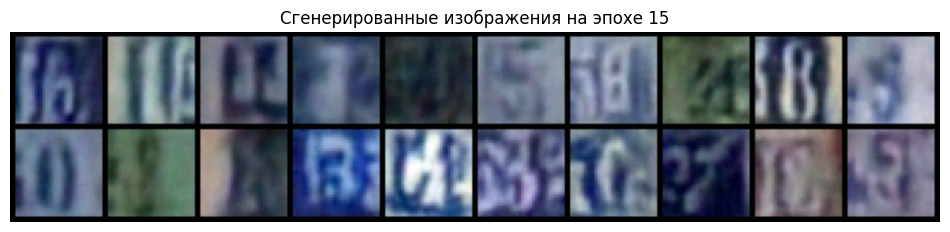

Epoch 16/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 16: Loss = 0.0180, MAE = 0.0794


Epoch 17/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 17: Loss = 0.0179, MAE = 0.0789


Epoch 18/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 18: Loss = 0.0181, MAE = 0.0790


Epoch 19/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 19: Loss = 0.0179, MAE = 0.0786


Epoch 20/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 20: Loss = 0.0178, MAE = 0.0780


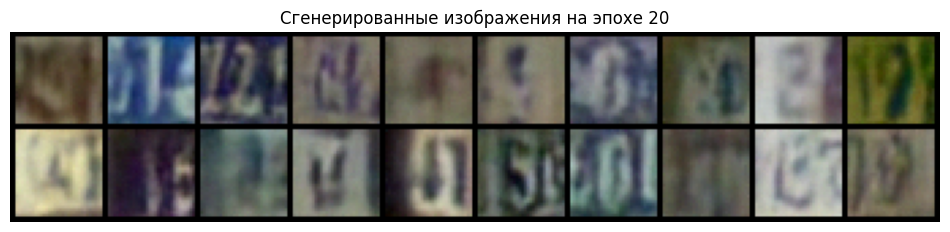

Epoch 21/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 21: Loss = 0.0175, MAE = 0.0774


Epoch 22/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 22: Loss = 0.0175, MAE = 0.0773


Epoch 23/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 23: Loss = 0.0171, MAE = 0.0764


Epoch 24/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 24: Loss = 0.0171, MAE = 0.0764


Epoch 25/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 25: Loss = 0.0168, MAE = 0.0757


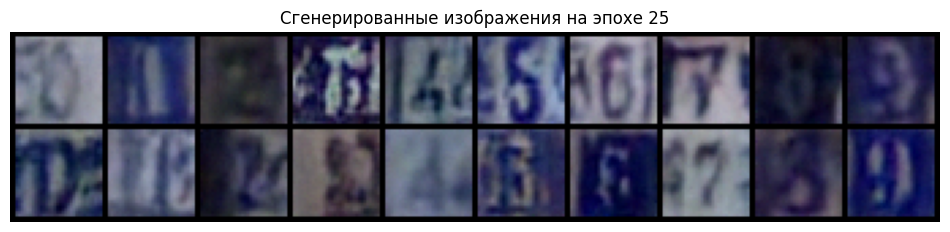

Epoch 26/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 26: Loss = 0.0167, MAE = 0.0755


Epoch 27/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bdb5408e480>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bdb5408e480>    self._shutdown_workers()

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    if w.is_alive():    
self._shutdown_workers() 
    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
       if w.is_alive(): 
^^ ^^ ^ ^ ^ ^ ^ ^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'
   ^ ^  ^ ^^^^
   File "/usr/li

Epoch 27: Loss = 0.0168, MAE = 0.0753


...

Epoch 28: Loss = 0.0166, MAE = 0.0751


Epoch 29/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 29: Loss = 0.0165, MAE = 0.0748


Epoch 30/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 30: Loss = 0.0164, MAE = 0.0746


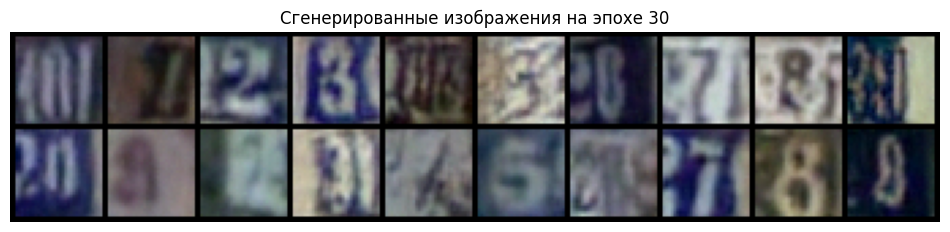

Epoch 31/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 31: Loss = 0.0163, MAE = 0.0743


Epoch 32/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 32: Loss = 0.0163, MAE = 0.0741


Epoch 33/120:   0%|          | 0/1145 [00:00<?, ?it/s]

...

Epoch 34/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 34: Loss = 0.0161, MAE = 0.0735


Epoch 35/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bdb5408e480>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bdb5408e480>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 35: Loss = 0.0161, MAE = 0.0735


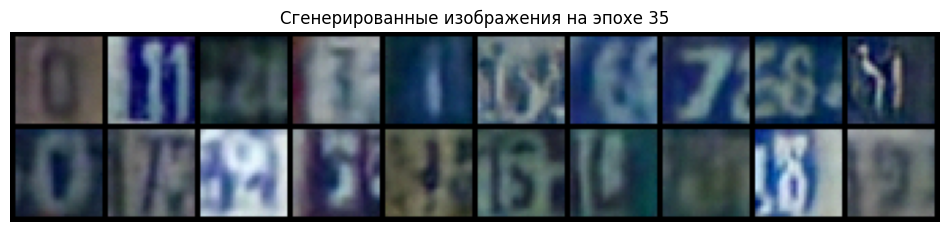

Epoch 36/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 36: Loss = 0.0162, MAE = 0.0738


Epoch 37/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 37: Loss = 0.0157, MAE = 0.0728


Epoch 38/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 38: Loss = 0.0159, MAE = 0.0730


Epoch 39/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 39: Loss = 0.0158, MAE = 0.0726


Epoch 40/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 40: Loss = 0.0158, MAE = 0.0728


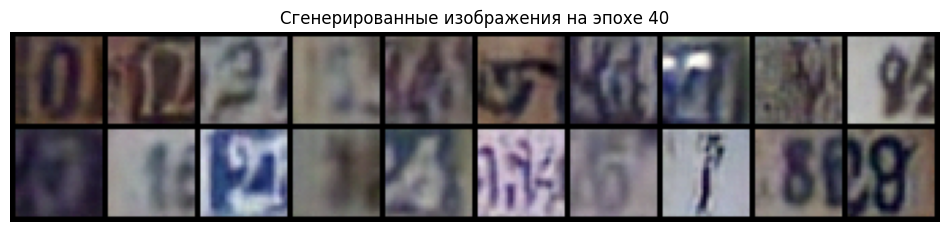

Epoch 41/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 41: Loss = 0.0160, MAE = 0.0729


Epoch 42/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 42: Loss = 0.0157, MAE = 0.0724


Epoch 43/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 43: Loss = 0.0155, MAE = 0.0720


Epoch 44/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 44: Loss = 0.0156, MAE = 0.0719


Epoch 45/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 45: Loss = 0.0155, MAE = 0.0719


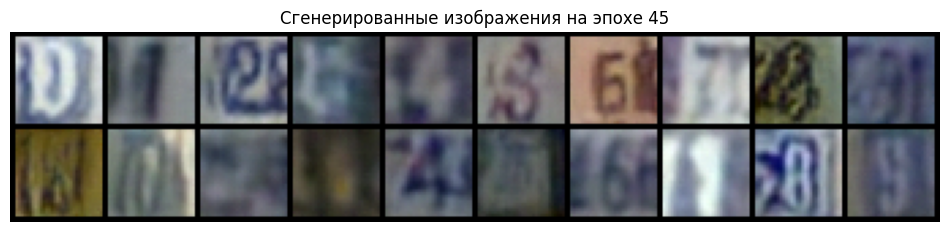

Epoch 46/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 46: Loss = 0.0153, MAE = 0.0716


Epoch 47/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bdb5408e480>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
Exception ignored in:   <function _MultiProcessingDataLoaderIter.__del__ at 0x7bdb5408e480>  
 Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
 ^    ^self._shutdown_workers()^^^^^
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    ^if w.is_alive():
^  ^
   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
       assert self._parent_pid == os.getpid(), 'can only test a child process'
   ^ ^ ^^ ^ ^  ^ ^ ^ ^^^^^^^^
  File 

Epoch 47: Loss = 0.0153, MAE = 0.0714


...

Epoch 48: Loss = 0.0152, MAE = 0.0714


Epoch 49/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 49: Loss = 0.0157, MAE = 0.0721


Epoch 50/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 50: Loss = 0.0153, MAE = 0.0712


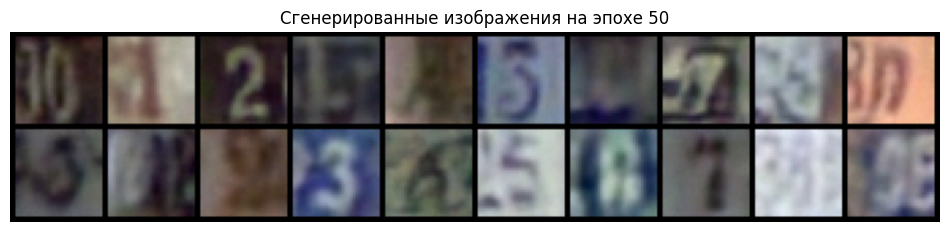

Epoch 51/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 51: Loss = 0.0152, MAE = 0.0709


Epoch 52/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 52: Loss = 0.0152, MAE = 0.0711


Epoch 53/120:   0%|          | 0/1145 [00:00<?, ?it/s]

...

Epoch 54/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 54: Loss = 0.0151, MAE = 0.0707


Epoch 55/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bdb5408e480>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bdb5408e480>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 55: Loss = 0.0150, MAE = 0.0706


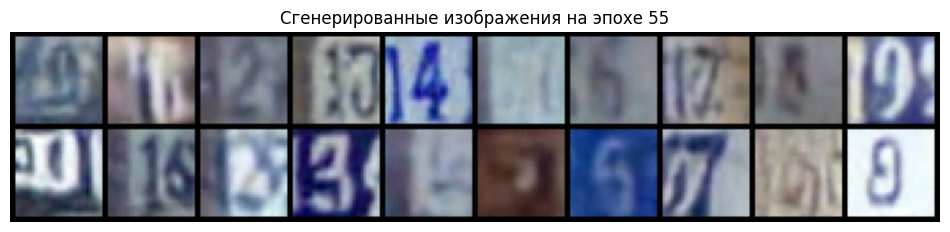

Epoch 56/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 56: Loss = 0.0151, MAE = 0.0706


Epoch 57/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 57: Loss = 0.0152, MAE = 0.0706


Epoch 58/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 58: Loss = 0.0150, MAE = 0.0705


Epoch 59/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 59: Loss = 0.0149, MAE = 0.0702


Epoch 60/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 60: Loss = 0.0150, MAE = 0.0702


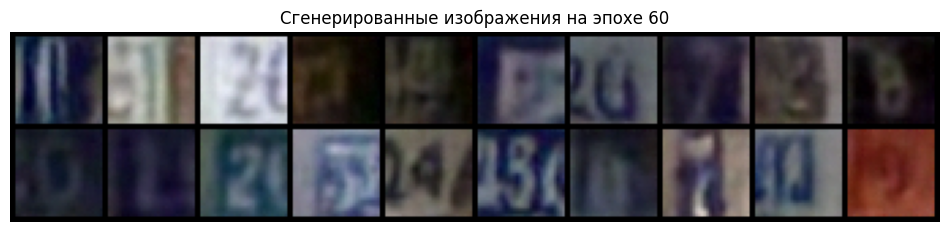

Epoch 61/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 61: Loss = 0.0151, MAE = 0.0702


Epoch 62/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 62: Loss = 0.0150, MAE = 0.0701


Epoch 63/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 63: Loss = 0.0149, MAE = 0.0701


Epoch 64/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 64: Loss = 0.0147, MAE = 0.0697


Epoch 65/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 65: Loss = 0.0148, MAE = 0.0697


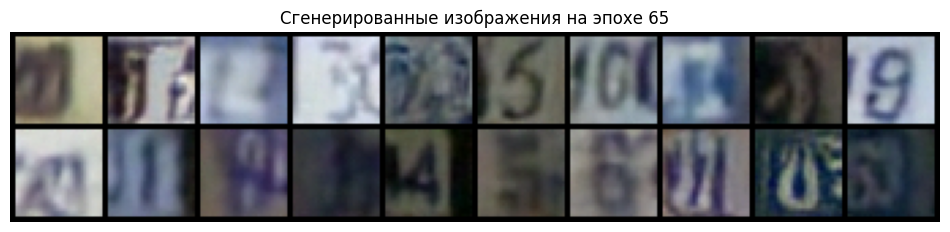

Epoch 66/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 66: Loss = 0.0145, MAE = 0.0693


Epoch 67/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bdb5408e480>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bdb5408e480>^^
Traceback (most recent call last):
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^    ^^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^
      File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
if w.is_alive():
     assert self._parent_pid == os.getpid(), 'can only test a child process' 
           ^^^^
^^^ ^^ ^^^  File "/usr/li

Epoch 67: Loss = 0.0149, MAE = 0.0700


...

Epoch 68: Loss = 0.0146, MAE = 0.0695


Epoch 69/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 69: Loss = 0.0146, MAE = 0.0693


Epoch 70/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 70: Loss = 0.0147, MAE = 0.0694


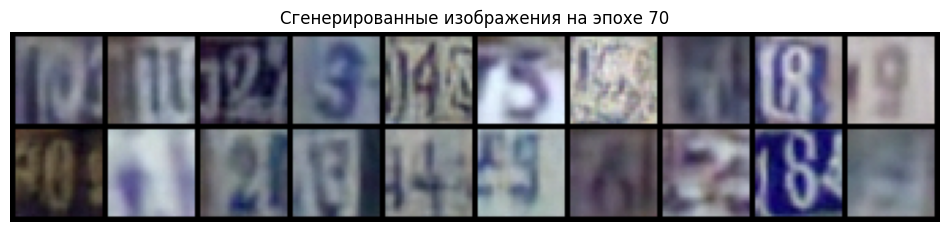

Epoch 71/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 71: Loss = 0.0148, MAE = 0.0694


Epoch 72/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 72: Loss = 0.0146, MAE = 0.0688


Epoch 73/120:   0%|          | 0/1145 [00:00<?, ?it/s]

...

Epoch 74/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 74: Loss = 0.0147, MAE = 0.0689


Epoch 75/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bdb5408e480>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bdb5408e480>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 75: Loss = 0.0148, MAE = 0.0693


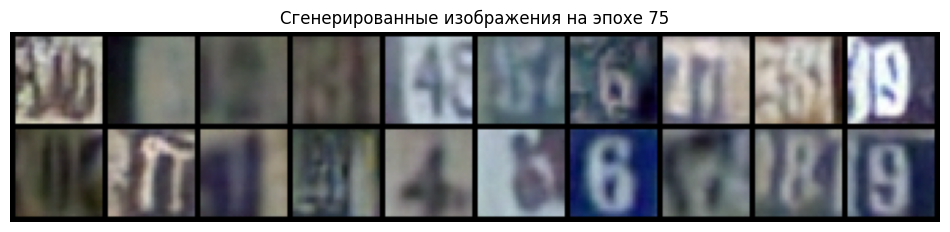

Epoch 76/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 76: Loss = 0.0149, MAE = 0.0697


Epoch 77/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 77: Loss = 0.0145, MAE = 0.0689


Epoch 78/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 78: Loss = 0.0145, MAE = 0.0687


Epoch 79/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 79: Loss = 0.0147, MAE = 0.0692


Epoch 80/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 80: Loss = 0.0147, MAE = 0.0690


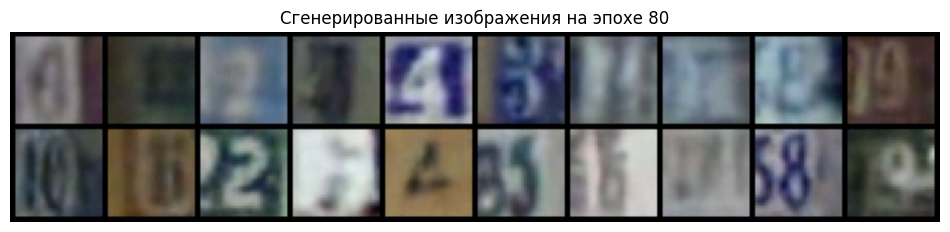

Epoch 81/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 81: Loss = 0.0143, MAE = 0.0683


Epoch 82/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 82: Loss = 0.0144, MAE = 0.0685


Epoch 83/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 83: Loss = 0.0145, MAE = 0.0686


Epoch 84/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 84: Loss = 0.0146, MAE = 0.0687


Epoch 85/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 85: Loss = 0.0145, MAE = 0.0684


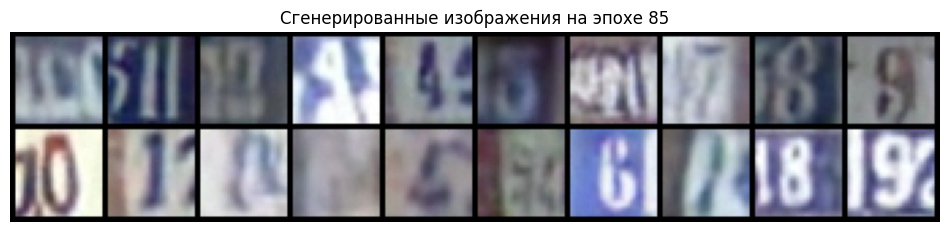

Epoch 86/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 86: Loss = 0.0146, MAE = 0.0688


Epoch 87/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 87: Loss = 0.0147, MAE = 0.0690


Epoch 88/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 88: Loss = 0.0143, MAE = 0.0683


Epoch 89/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 89: Loss = 0.0142, MAE = 0.0680


Epoch 90/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 90: Loss = 0.0144, MAE = 0.0682


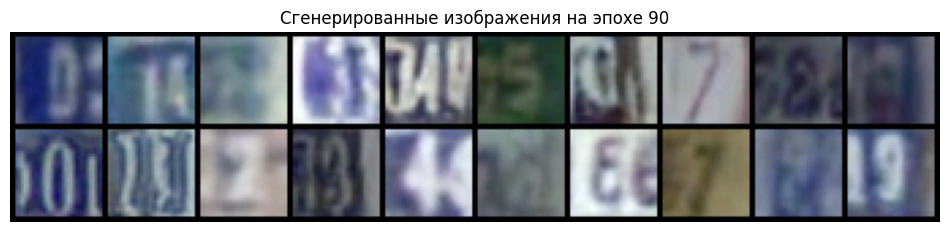

Epoch 91/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 91: Loss = 0.0146, MAE = 0.0687


Epoch 92/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 92: Loss = 0.0143, MAE = 0.0682


Epoch 93/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 93: Loss = 0.0143, MAE = 0.0682


Epoch 94/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 94: Loss = 0.0143, MAE = 0.0680


Epoch 95/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 95: Loss = 0.0142, MAE = 0.0678


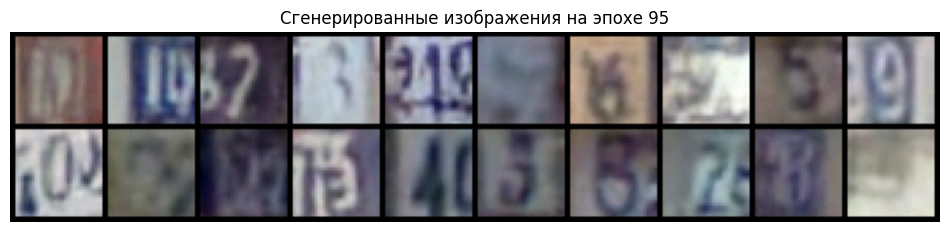

Epoch 96/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 96: Loss = 0.0145, MAE = 0.0684


Epoch 97/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 97: Loss = 0.0144, MAE = 0.0680


Epoch 98/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 98: Loss = 0.0145, MAE = 0.0682


Epoch 99/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 99: Loss = 0.0143, MAE = 0.0680


Epoch 100/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 100: Loss = 0.0141, MAE = 0.0675


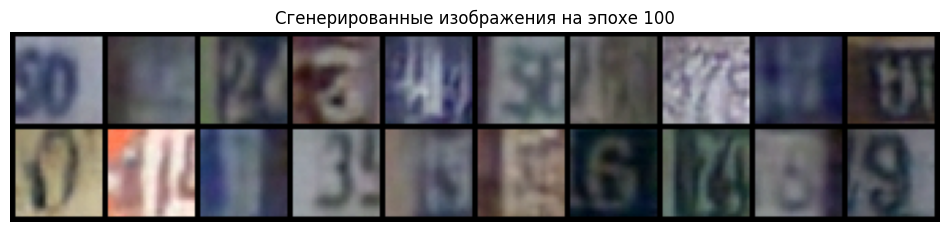

Epoch 101/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 101: Loss = 0.0141, MAE = 0.0676


Epoch 102/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bdb5408e480>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bdb5408e480>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 102: Loss = 0.0145, MAE = 0.0683


...

Epoch 103: Loss = 0.0142, MAE = 0.0679


Epoch 104/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 104: Loss = 0.0143, MAE = 0.0677


Epoch 105/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 105: Loss = 0.0143, MAE = 0.0682


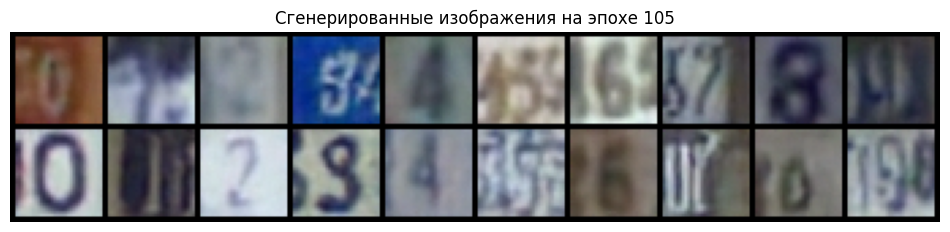

Epoch 106/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 106: Loss = 0.0142, MAE = 0.0677


Epoch 107/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 107: Loss = 0.0144, MAE = 0.0679


Epoch 108/120:   0%|          | 0/1145 [00:00<?, ?it/s]

...

Epoch 109/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 109: Loss = 0.0141, MAE = 0.0676


Epoch 110/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bdb5408e480>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bdb5408e480>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 110: Loss = 0.0141, MAE = 0.0675


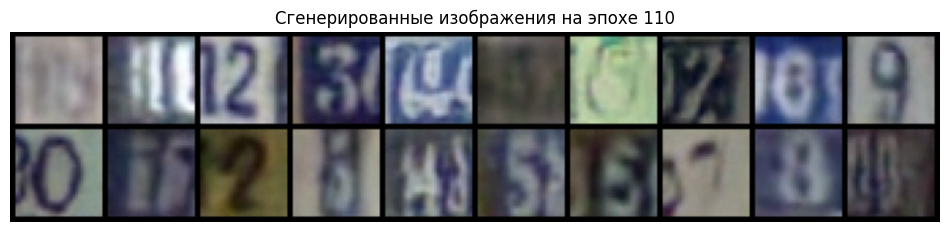

Epoch 111/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 111: Loss = 0.0144, MAE = 0.0680


Epoch 112/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 112: Loss = 0.0143, MAE = 0.0676


Epoch 113/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 113: Loss = 0.0141, MAE = 0.0676


Epoch 114/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 114: Loss = 0.0144, MAE = 0.0677


Epoch 115/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 115: Loss = 0.0141, MAE = 0.0674


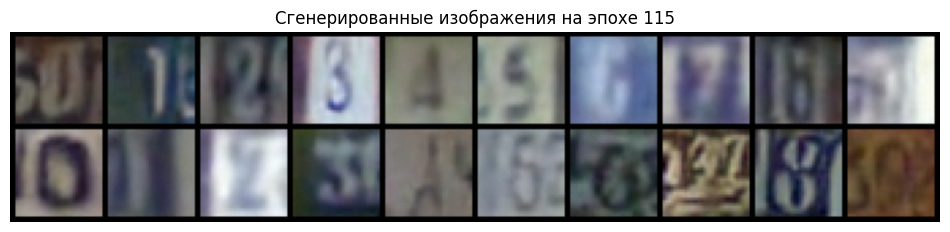

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bdb5408e480>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7bdb5408e480> 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
     if w.is_alive():
           ^ ^^ ^^^^^^^^^^^^^^^^^^^^^


Epoch 116/120:   0%|          | 0/1145 [00:01<?, ?it/s]

^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError^: 
can only test a child process
AssertionError: can only test a child process


Epoch 116: Loss = 0.0142, MAE = 0.0676


Epoch 117/120:   0%|          | 0/1145 [00:00<?, ?it/s]

...

Epoch 118: Loss = 0.0144, MAE = 0.0682


Epoch 119/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 119: Loss = 0.0141, MAE = 0.0674


Epoch 120/120:   0%|          | 0/1145 [00:00<?, ?it/s]

Epoch 120: Loss = 0.0143, MAE = 0.0677


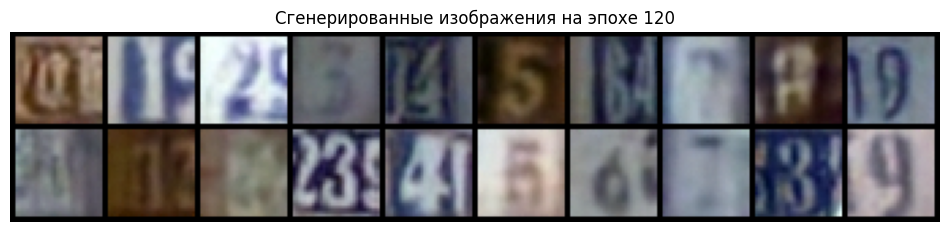

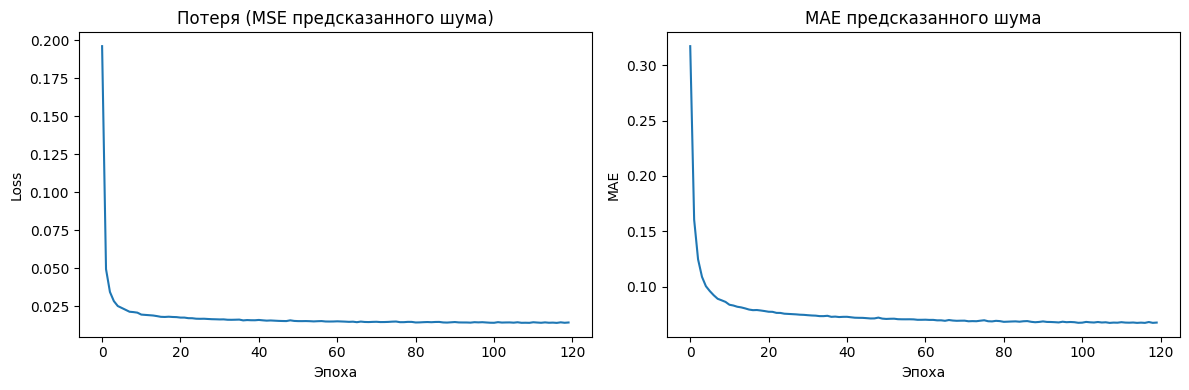

In [ ]:
def train_diffusion(model, noise_scheduler, train_loader, epochs=100, lr=1e-4, device='cuda'):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

    losses = []
    mae_errors = []   # MAE между предсказанным и истинным шумом (для визуализации)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_mae = 0
        count = 0

        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        for batch_idx, (images, labels) in enumerate(pbar):
            images = images.to(device)
            labels = labels.to(device)
            batch_size = images.size(0)

            # Случайные временные шаги
            t = torch.randint(0, noise_scheduler.num_timesteps, (batch_size,), device=device)

            # Добавить шум к изображениям
            noise = torch.randn_like(images)
            x_t, _ = noise_scheduler.q_sample(images, t, noise)

            # Предсказать шум
            predicted_noise = model(x_t, t, labels)

            # Потеря: MSE между предсказанным и истинным шумом
            loss = F.mse_loss(predicted_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * batch_size
            # MAE между предсказанным и истинным шумом
            mae = torch.mean(torch.abs(predicted_noise - noise)).item() * batch_size
            total_mae += mae
            count += batch_size

            pbar.set_postfix({'loss': loss.item(), 'mae': mae / batch_size})

        avg_loss = total_loss / count
        avg_mae = total_mae / count
        losses.append(avg_loss)
        mae_errors.append(avg_mae)

        scheduler.step()
        print(f'Epoch {epoch+1}: Loss = {avg_loss:.4f}, MAE = {avg_mae:.4f}')

        # Каждые 5 эпох показываем сгенерированные примеры
        if (epoch + 1) % 5 == 0:
            model.eval()
            with torch.no_grad():
                # Генерируем по одному примеру для каждого класса
                class_labels = torch.arange(10, device=device).repeat(2)
                generated = noise_scheduler.sample(model, 20, class_labels, img_shape=(3,32,32), device=device)
                generated = generated / 2 + 0.5
                grid = make_grid(generated, nrow=10, padding=2)
                plt.figure(figsize=(12, 3))
                plt.imshow(grid.permute(1,2,0).cpu())
                plt.axis('off')
                plt.title(f'Сгенерированные изображения на эпохе {epoch+1}')
                plt.show()

    return losses, mae_errors

# Инициализация
noise_scheduler = NoiseScheduler(num_timesteps=1000, beta_start=1e-4, beta_end=0.02, schedule='linear')
noise_scheduler.to(device)
model = SimpleUNet(image_channels=3, time_emb_dim=128, class_emb_dim=10, num_classes=10)

# Обучение
diffusion_losses, diffusion_mae = train_diffusion(model, noise_scheduler, train_loader, epochs=120, lr=1e-4, device=device)


plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(diffusion_losses)
plt.title('Потеря (MSE предсказанного шума)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(diffusion_mae)
plt.title('MAE предсказанного шума')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.tight_layout()
plt.show()

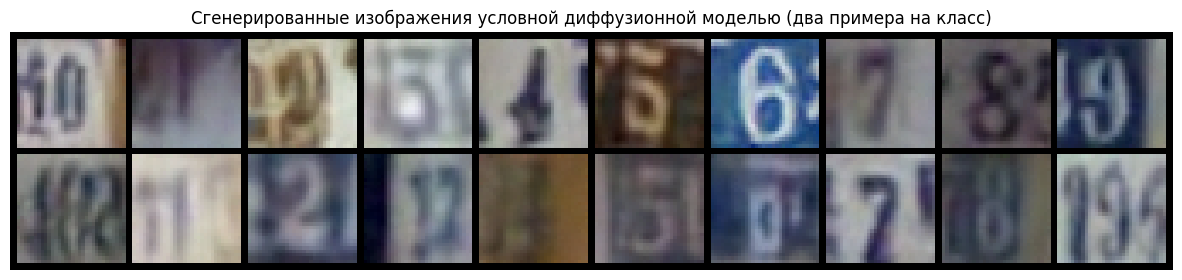

In [ ]:
model.eval()
with torch.no_grad():
    class_labels = torch.arange(10, device=device).repeat(2)
    generated = noise_scheduler.sample(model, 20, class_labels, img_shape=(3,32,32), device=device)
    generated = generated / 2 + 0.5  # denormalize

# Визуализация
plt.figure(figsize=(15, 5))
grid = make_grid(generated, nrow=10, padding=2)
plt.imshow(grid.permute(1,2,0).cpu())
plt.axis('off')
plt.title('Сгенерированные изображения условной диффузионной моделью (два примера на класс)')
plt.show()

Сохраняем модель.

In [ ]:
import os

save_dir = '/content/drive/MyDrive/pet_project_models'
os.makedirs(save_dir, exist_ok=True)
print(f"Папка для сохранения: {save_dir}")

Папка создана: /content/drive/MyDrive/pet_project_models


In [ ]:
# Формируем имя файла, отражающее основные параметры модели
model_name = f"unet_ep120_bs{batch_size}_t1000"
model_path = os.path.join(save_dir, f"{model_name}.pth")
torch.save(model.state_dict(), model_path)
print(f"Модель сохранена в {model_path}")

# Сохраняем полную конфигурацию модели
model_config = {
    'image_channels': 3,
    'num_classes': 10,
    'time_emb_dim': 128,
    'class_emb_dim': 10,
    'attention_layers': ['down2', 'up2'],  # где были attention блоки
    'norm_type': 'GroupNorm',
    'use_ema': True,
    'epochs_trained': 120,
    'batch_size': batch_size,
    'optimizer': 'Adam',
    'lr': 1e-4,
    'scheduler': 'CosineAnnealingLR',
}
config_path = os.path.join(save_dir, f"{model_name}_config.pth")
torch.save(model_config, config_path)

# Сохраняем параметры шумового планировщика
scheduler_config = {
    'num_timesteps': noise_scheduler.num_timesteps,
    'beta_start': 1e-4,
    'beta_end': 0.02,
}
scheduler_config_path = os.path.join(save_dir, f"{model_name}_scheduler.pth")
torch.save(scheduler_config, scheduler_config_path)



history = {
    'losses': diffusion_losses,
    'mae': diffusion_mae,
}
history_path = os.path.join(save_dir, f"{model_name}_history.pth")
torch.save(history, history_path)

print("Все файлы сохранены.")

Модель сохранена в /content/drive/MyDrive/pet_project_models/unet_ep120_bs64_t1000.pth
Все файлы сохранены.
